# House Price Prediction — Linear Regression

**Goal:** Predict a continuous number (house sale price) instead of a category.
This is a **regression** problem — the target, `SalePrice`, is a dollar
amount, not a "yes/no" label.

**Dataset:** [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)
(Kaggle) — 1,460 houses in Ames, Iowa, with 79 explanatory variables.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("train.csv")
df.shape


(1460, 81)

## 2. First look at the data

In [2]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## 3. Select features

I picked 5 features I believe most affect a house's sale price:

- **`OverallQual`** — overall material and finish quality (1-10 rating).
  Usually the single strongest predictor of price in this dataset.
- **`GrLivArea`** — above-ground living area in square feet. Bigger homes
  generally sell for more.
- **`GarageCars`** — size of garage in car capacity, a strong proxy for
  overall house size and amenities.
- **`TotalBsmtSF`** — total basement square footage, adds usable space.
- **`YearBuilt`** — newer homes tend to sell for more than older ones,
  all else equal.

None of these 5 columns have missing values in the training set, so no
imputation is needed for this feature set.


In [4]:
features = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "YearBuilt"]
X = df[features]
y = df["SalePrice"]

print(X.isnull().sum())
X.describe()


OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
YearBuilt      0
dtype: int64


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,1057.429452,1971.267808
std,1.382997,525.480383,0.747315,438.705324,30.202904
min,1.000000,334.000000,0.000000,0.000000,1872.000000
25%,5.000000,1129.500000,1.000000,795.750000,1954.000000
50%,6.000000,1464.000000,2.000000,991.500000,1973.000000
75%,7.000000,1776.750000,2.000000,1298.250000,2000.000000
max,10.000000,5642.000000,4.000000,6110.000000,2010.000000


## 4. Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (1168, 5)
Test size: (292, 5)


## 5. Train a Linear Regression model

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## 6. Evaluate — RMSE and R²

In [7]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: ${rmse:,.2f}")
print(f"R^2 score: {r2:.4f}")


RMSE: $39,763.30
R^2 score: 0.7939


## 7. Predicted vs. Actual — scatter plot

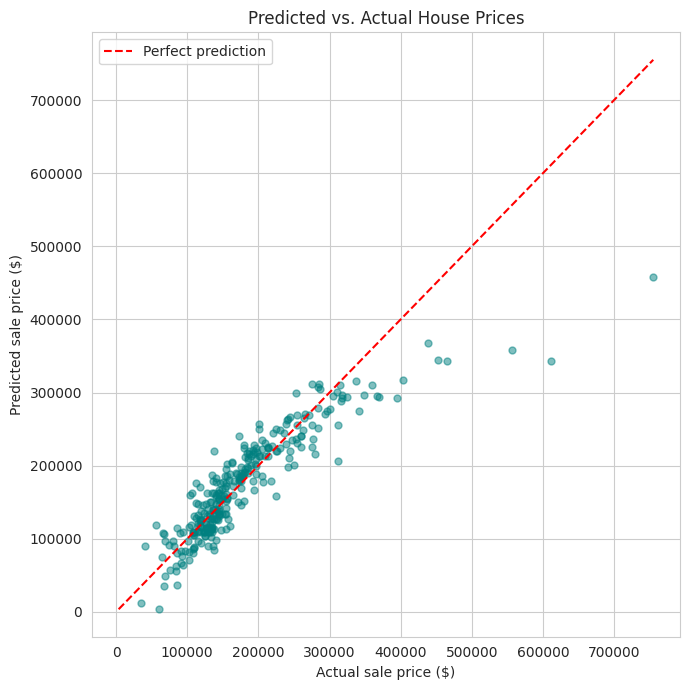

In [8]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, s=25, color="teal")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual sale price ($)")
plt.ylabel("Predicted sale price ($)")
plt.title("Predicted vs. Actual House Prices")
plt.legend()
plt.tight_layout()
plt.show()


The closer the points cluster around the red dashed line, the better the
model's predictions. Here most points sit fairly close to the line for
mid-range houses, but the spread grows for the most expensive homes — the
model tends to underpredict the priciest houses, visible as points falling
below the line at the top right.


## 8. Feature coefficients

In [9]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(f"Intercept: {model.intercept_:,.2f}")
coef_df


Intercept: -694,533.36


,feature,coefficient
0,OverallQual,20392.513001
2,GarageCars,15144.237204
4,YearBuilt,315.923350
1,GrLivArea,48.809801
3,TotalBsmtSF,25.365319


## 9. What does the R² score mean? (plain English)

Our model's R² score tells us roughly what share of the difference in house
prices from one home to another our five features can explain — the rest
comes down to things we didn't include, like neighborhood, lot shape, or
recent renovations, plus some amount of unpredictable noise. Think of it like
a weather forecaster who gets the general temperature trend right most days
but still misses on unusually hot or cold ones: our model gives a genuinely
useful ballpark estimate of what a house is worth, but nobody should treat
its number as exact — it will be noticeably off for some individual homes,
especially unusually large or expensive ones.
